In [1]:
# ============================================================
# 1. YOLO 데이터셋 상태 확인
# ============================================================

from pathlib import Path

DATASET_DIR = Path("/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset")

image_dir = DATASET_DIR / "images" / "train"
label_dir = DATASET_DIR / "labels" / "train"

image_files = list(image_dir.glob("*"))
label_files = list(label_dir.glob("*.txt"))

print("이미지 수:", len(image_files))
print("라벨 txt 수:", len(label_files))

image_stems = {p.stem for p in image_files}
label_stems = {p.stem for p in label_files}

print("매칭 수:", len(image_stems & label_stems))
print("라벨 없는 이미지 수:", len(image_stems - label_stems))
print("이미지 없는 라벨 수:", len(label_stems - image_stems))

이미지 수: 535
라벨 txt 수: 529
매칭 수: 529
라벨 없는 이미지 수: 6
이미지 없는 라벨 수: 0


In [2]:
# ============================================================
# 2. lesion 단일 클래스 YAML 다시 생성
# ============================================================

yaml_path = DATASET_DIR / "lesion_data.yaml"

yaml_text = f"""
path: {DATASET_DIR}
train: images/train
val: images/train

names:
  0: lesion
"""

with open(yaml_path, "w", encoding="utf-8") as f:
    f.write(yaml_text.strip())

print(yaml_path)
print(yaml_text)

/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/lesion_data.yaml

path: /home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset
train: images/train
val: images/train

names:
  0: lesion



In [3]:
# ============================================================
# 3. YOLOv8 재학습
# ============================================================

from ultralytics import YOLO

yolo_base = YOLO("yolov8n.pt")

results = yolo_base.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=8,
    device=0,
    project="/home/harry/Re_leaf_Project/yolo_runs",
    name="reaf_lesion_yolov8n_529labels",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.50 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.49 🚀 Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/lesion_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, 

In [22]:
# ============================================================
# 6-8. ambiguous_tests 방식 A 일괄 테스트
# YOLO 병반 유무 필터 + ConvNeXt 전체 이미지 분류
# ============================================================

ambiguous_tests = [
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/사과검은썩음병1.jpg",
        "selected_crop": "Apple"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/사과삼나무사과녹병1.jpg",
        "selected_crop": "Apple"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/사과삼나무사과녹병2.jpg",
        "selected_crop": "Apple"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/옥수수북부잎마름병1.jpg",
        "selected_crop": "Corn_(maize)"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/옥수수세르코스포라잎반점병2.jpg",
        "selected_crop": "Corn_(maize)"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/토마토건강1.jpg",
        "selected_crop": "Tomato"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/토마토건강2.jpg",
        "selected_crop": "Tomato"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/토마토전기역병1.jpg",
        "selected_crop": "Tomato"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/토마토점무늬병1.jpg",
        "selected_crop": "Tomato"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/토마토점무늬병2.webp",
        "selected_crop": "Tomato"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/포도건강1.jpg",
        "selected_crop": "Grape"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/포도잎마름병1.jpg",
        "selected_crop": "Grape"
    },
]

In [5]:
# ============================================================
# 4. 새 YOLO 모델 로드
# ============================================================

from ultralytics import YOLO
from pathlib import Path
from PIL import Image
from IPython.display import display
import torch
import pandas as pd

NEW_YOLO_MODEL_PATH = Path("/home/harry/Re_leaf_Project/yolo_runs/reaf_lesion_yolov8n_529labels/weights/best.pt")

yolo_model = YOLO(str(NEW_YOLO_MODEL_PATH))

print("새 YOLO 로드 완료:", NEW_YOLO_MODEL_PATH)

새 YOLO 로드 완료: /home/harry/Re_leaf_Project/yolo_runs/reaf_lesion_yolov8n_529labels/weights/best.pt


In [7]:
# ============================================================
# 5. MODEL PATH SETTINGS
# ============================================================

from pathlib import Path

# YOLO lesion detector
YOLO_MODEL_PATH = (
    "/home/harry/Re_leaf_Project/"
    "yolo_runs/reaf_lesion_yolov8n_529labels/weights/best.pt"
)

# ConvNeXt classifier
CONVNEXT_MODEL_PATH = (
    "/home/harry/Re_leaf_Project/"
    "cp_convnext_tiny_38realmix_pvprep30_finetuned.pth"
)

# class names
CLASS_NAMES_PATH = (
    "/home/harry/Re_leaf_Project/"
    "class_names_38cls.json"
)

print("YOLO_MODEL_PATH:")
print(YOLO_MODEL_PATH)

print("\nCONVNEXT_MODEL_PATH:")
print(CONVNEXT_MODEL_PATH)

print("\nCLASS_NAMES_PATH:")
print(CLASS_NAMES_PATH)

YOLO_MODEL_PATH:
/home/harry/Re_leaf_Project/yolo_runs/reaf_lesion_yolov8n_529labels/weights/best.pt

CONVNEXT_MODEL_PATH:
/home/harry/Re_leaf_Project/cp_convnext_tiny_38realmix_pvprep30_finetuned.pth

CLASS_NAMES_PATH:
/home/harry/Re_leaf_Project/class_names_38cls.json


In [8]:
# ============================================================
# 6. IMPORTS + DEVICE
# ============================================================

import torch
import torch.nn as nn

from torchvision import models, transforms
from ultralytics import YOLO

from PIL import Image
from IPython.display import display

import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 device:", device)

사용 device: cuda


In [9]:
# ============================================================
# 7. class_names_38cls 로드
# ============================================================

import json

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names_38cls = json.load(f)

print("클래스 수:", len(class_names_38cls))

print("\n첫 10개 클래스:")
for c in class_names_38cls[:10]:
    print(c)

클래스 수: 38

첫 10개 클래스:
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight


In [10]:
# ============================================================
# 8. ConvNeXt Tiny 모델 구조 생성
# ============================================================

NUM_CLASSES = len(class_names_38cls)

convnext_model = models.convnext_tiny(weights=None)

in_features = convnext_model.classifier[2].in_features

convnext_model.classifier[2] = nn.Linear(
    in_features,
    NUM_CLASSES
)

convnext_model = convnext_model.to(device)

print("ConvNeXt Tiny 모델 생성 완료")

ConvNeXt Tiny 모델 생성 완료


In [11]:
# ============================================================
# 9. ConvNeXt weight 로드
# ============================================================

state_dict = torch.load(
    CONVNEXT_MODEL_PATH,
    map_location=device
)

convnext_model.load_state_dict(state_dict)

convnext_model.eval()

print("ConvNeXt weight 로드 완료:")
print(CONVNEXT_MODEL_PATH)

ConvNeXt weight 로드 완료:
/home/harry/Re_leaf_Project/cp_convnext_tiny_38realmix_pvprep30_finetuned.pth


/tmp/ipykernel_42449/2309043644.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


In [12]:
# ============================================================
# 10. YOLO 모델 로드
# ============================================================

yolo_model = YOLO(YOLO_MODEL_PATH)

print("YOLO 모델 로드 완료:")
print(YOLO_MODEL_PATH)

YOLO 모델 로드 완료:
/home/harry/Re_leaf_Project/yolo_runs/reaf_lesion_yolov8n_529labels/weights/best.pt


In [13]:
# ============================================================
# 11. ConvNeXt 전처리
# ============================================================

convnext_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("ConvNeXt transform 준비 완료")

ConvNeXt transform 준비 완료


In [14]:
# ============================================================
# 12. ConvNeXt 전체 이미지 분류 함수
# ============================================================

def predict_full_image_convnext(image_path, topk=5):

    image = Image.open(image_path).convert("RGB")

    input_tensor = convnext_transform(image)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        outputs = convnext_model(input_tensor)

        probs = torch.softmax(outputs, dim=1)[0]

    top_probs, top_indices = torch.topk(
        probs,
        k=topk
    )

    results = []

    for prob, idx in zip(top_probs, top_indices):

        results.append({
            "class_name": class_names_38cls[idx.item()],
            "confidence": float(prob.item())
        })

    return results

In [15]:
# ============================================================
# 13. 방식 A
# YOLO 병반 유무 필터
# + ConvNeXt 전체 이미지 분류
# ============================================================

def predict_reaf_mode_a(
    image_path,
    yolo_conf_thres=0.01,
    topk=5,
    show=True
):

    image_path = Path(image_path)

    # --------------------------------------------------------
    # 1. YOLO 병반 탐지
    # --------------------------------------------------------

    yolo_results = yolo_model.predict(
        source=str(image_path),
        conf=yolo_conf_thres,
        imgsz=640,
        verbose=False
    )

    boxes = yolo_results[0].boxes

    if boxes is None or len(boxes) == 0:

        yolo_detected = False
        yolo_max_conf = 0.0
        box_count = 0

    else:

        yolo_detected = True

        yolo_max_conf = float(
            boxes.conf.max().cpu().item()
        )

        box_count = len(boxes)

    # --------------------------------------------------------
    # 2. ConvNeXt 전체 이미지 분류
    # --------------------------------------------------------

    convnext_preds = predict_full_image_convnext(
        image_path=image_path,
        topk=topk
    )

    top1_class = convnext_preds[0]["class_name"]

    # --------------------------------------------------------
    # 3. 최종 판단
    # --------------------------------------------------------

    if yolo_detected:

        final_decision = (
            "병반 탐지됨 → ConvNeXt 질병 분류 결과 사용"
        )

    else:

        if "healthy" in top1_class.lower():

            final_decision = (
                "병반 미탐지 + ConvNeXt healthy "
                "→ 건강 가능성 높음"
            )

        else:

            final_decision = (
                "병반 미탐지 + ConvNeXt disease 예측 "
                "→ 판단 어려움"
            )

    # --------------------------------------------------------
    # 4. 출력
    # --------------------------------------------------------

    if show:

        print("=" * 100)

        print("이미지:")
        print(image_path.name)

        print("\nYOLO threshold:")
        print(yolo_conf_thres)

        display(
            Image.open(image_path).resize((300, 300))
        )

        print("\nYOLO 병반 탐지 여부:")
        print(yolo_detected)

        print("\nYOLO 최고 confidence:")
        print(round(yolo_max_conf, 4))

        print("\nYOLO box 개수:")
        print(box_count)

        print("\nConvNeXt Top5:")

        for rank, pred in enumerate(
            convnext_preds,
            start=1
        ):

            print(
                f"Top{rank}: "
                f"{pred['class_name']} "
                f"/ conf={pred['confidence']:.4f}"
            )

        print("\n최종 판단:")
        print(final_decision)

    return {

        "image_path": str(image_path),

        "yolo_detected": yolo_detected,

        "yolo_confidence": yolo_max_conf,

        "box_count": box_count,

        "convnext_predictions": convnext_preds,

        "final_decision": final_decision
    }

In [26]:
# ============================================================
# 14. ambiguous_tests 실행
# threshold 0.01 / 0.02 비교
# ============================================================

thresholds = [0.05, 0.08, 0.10, 0.15, 0.20]

compare_results = []

for thres in thresholds:

    print("\n" + "#" * 100)
    print(f"YOLO THRESHOLD TEST: {thres}")

    for item in ambiguous_tests:

        result = predict_reaf_mode_a(
            image_path=item["img_path"],
            yolo_conf_thres=thres,
            topk=5,
            show=False
        )

        result["selected_crop"] = item["selected_crop"]

        result["threshold"] = thres

        compare_results.append(result)

print("\n비교 완료")


####################################################################################################
YOLO THRESHOLD TEST: 0.05

####################################################################################################
YOLO THRESHOLD TEST: 0.08

####################################################################################################
YOLO THRESHOLD TEST: 0.1

####################################################################################################
YOLO THRESHOLD TEST: 0.15

####################################################################################################
YOLO THRESHOLD TEST: 0.2

비교 완료


In [27]:
# ============================================================
# 17. ConvNeXt 단독 vs YOLO+ConvNeXt threshold 5개 비교
# 이미지 같이 보기용 DataFrame 생성
# ============================================================

from pathlib import Path
from PIL import Image
from IPython.display import display
import pandas as pd


# 비교할 threshold 후보들
YOLO_THRESHOLDS = [0.05, 0.08, 0.10, 0.15, 0.20]


def predict_yolo_only(image_path, yolo_conf_thres=0.10):
    image_path = Path(image_path)

    yolo_results = yolo_model.predict(
        source=str(image_path),
        conf=yolo_conf_thres,
        imgsz=640,
        verbose=False
    )

    boxes = yolo_results[0].boxes

    if boxes is None or len(boxes) == 0:
        return {
            "yolo_detected": False,
            "yolo_confidence": 0.0,
            "box_count": 0
        }

    return {
        "yolo_detected": True,
        "yolo_confidence": float(boxes.conf.max().cpu().item()),
        "box_count": len(boxes)
    }


def final_decision_by_mode_a(yolo_detected, conv_top1):
    if yolo_detected:
        return "병반 탐지됨 → ConvNeXt 결과 사용"

    if "healthy" in conv_top1.lower():
        return "병반 미탐지 + healthy → 건강 가능성 높음"

    return "병반 미탐지 + disease → 판단 어려움"


compare_multi_rows = []

for item in ambiguous_tests:
    img_path = Path(item["img_path"])
    selected_crop = item["selected_crop"]

    # ConvNeXt 단독 결과
    conv_preds = predict_full_image_convnext(img_path, topk=5)

    conv_top1 = conv_preds[0]["class_name"]
    conv_top1_conf = conv_preds[0]["confidence"]

    row = {
        "file_name": img_path.name,
        "img_path": str(img_path),
        "selected_crop": selected_crop,

        "conv_only_top1": conv_top1,
        "conv_only_top1_conf": round(conv_top1_conf, 4),
        "conv_only_top2": conv_preds[1]["class_name"],
        "conv_only_top2_conf": round(conv_preds[1]["confidence"], 4),
        "conv_only_top3": conv_preds[2]["class_name"],
        "conv_only_top3_conf": round(conv_preds[2]["confidence"], 4),
    }

    # threshold 후보별 YOLO 결과 추가
    for thres in YOLO_THRESHOLDS:
        yolo_result = predict_yolo_only(
            img_path,
            yolo_conf_thres=thres
        )

        decision = final_decision_by_mode_a(
            yolo_result["yolo_detected"],
            conv_top1
        )

        thres_key = str(thres).replace(".", "_")

        row[f"yolo_{thres_key}_detected"] = yolo_result["yolo_detected"]
        row[f"yolo_{thres_key}_conf"] = round(yolo_result["yolo_confidence"], 4)
        row[f"yolo_{thres_key}_box_count"] = yolo_result["box_count"]
        row[f"mode_a_{thres_key}_decision"] = decision

    compare_multi_rows.append(row)


df_compare_multi = pd.DataFrame(compare_multi_rows)

df_compare_multi

,file_name,img_path,selected_crop,conv_only_top1,conv_only_top1_conf,conv_only_top2,conv_only_top2_conf,conv_only_top3,conv_only_top3_conf,yolo_0_05_detected,...,yolo_0_1_box_count,mode_a_0_1_decision,yolo_0_15_detected,yolo_0_15_conf,yolo_0_15_box_count,mode_a_0_15_decision,yolo_0_2_detected,yolo_0_2_conf,yolo_0_2_box_count,mode_a_0_2_decision
0,사과검은썩음병1.jpg,/home/harry/Re_leaf_Project/Test_image/사과검은썩음병...,Apple,Apple___Apple_scab,0.9639,Apple___healthy,0.0198,Apple___Black_rot,0.0087,True,...,15,병반 탐지됨 → ConvNeXt 결과 사용,True,0.5449,13,병반 탐지됨 → ConvNeXt 결과 사용,True,0.5449,7,병반 탐지됨 → ConvNeXt 결과 사용
1,사과삼나무사과녹병1.jpg,/home/harry/Re_leaf_Project/Test_image/사과삼나무사과...,Apple,Grape___Black_rot,0.7967,Apple___Cedar_apple_rust,0.1066,Apple___Black_rot,0.0783,True,...,3,병반 탐지됨 → ConvNeXt 결과 사용,True,0.7204,2,병반 탐지됨 → ConvNeXt 결과 사용,True,0.7204,2,병반 탐지됨 → ConvNeXt 결과 사용
2,사과삼나무사과녹병2.jpg,/home/harry/Re_leaf_Project/Test_image/사과삼나무사과...,Apple,Apple___Black_rot,0.6907,"Pepper,_bell___Bacterial_spot",0.1349,Apple___Cedar_apple_rust,0.1184,True,...,10,병반 탐지됨 → ConvNeXt 결과 사용,True,0.5852,6,병반 탐지됨 → ConvNeXt 결과 사용,True,0.5852,4,병반 탐지됨 → ConvNeXt 결과 사용
3,옥수수북부잎마름병1.jpg,/home/harry/Re_leaf_Project/Test_image/옥수수북부잎마...,Corn_(maize),Corn_(maize)___Common_rust_,0.9303,Corn_(maize)___Northern_Leaf_Blight,0.0697,Apple___Cedar_apple_rust,0.0000,True,...,16,병반 탐지됨 → ConvNeXt 결과 사용,True,0.5053,7,병반 탐지됨 → ConvNeXt 결과 사용,True,0.5053,3,병반 탐지됨 → ConvNeXt 결과 사용
4,옥수수세르코스포라잎반점병2.jpg,/home/harry/Re_leaf_Project/Test_image/옥수수세르코스...,Corn_(maize),Corn_(maize)___Northern_Leaf_Blight,0.5627,Corn_(maize)___Common_rust_,0.4354,Apple___Cedar_apple_rust,0.0005,True,...,8,병반 탐지됨 → ConvNeXt 결과 사용,True,0.2797,2,병반 탐지됨 → ConvNeXt 결과 사용,True,0.2797,2,병반 탐지됨 → ConvNeXt 결과 사용
5,토마토건강1.jpg,/home/harry/Re_leaf_Project/Test_image/토마토건강1.jpg,Tomato,Tomato___Late_blight,0.9936,Tomato___healthy,0.0054,Corn_(maize)___healthy,0.0004,True,...,0,병반 미탐지 + disease → 판단 어려움,False,0.0000,0,병반 미탐지 + disease → 판단 어려움,False,0.0000,0,병반 미탐지 + disease → 판단 어려움
6,토마토건강2.jpg,/home/harry/Re_leaf_Project/Test_image/토마토건강2.jpg,Tomato,Apple___Apple_scab,0.8217,Apple___Cedar_apple_rust,0.1320,Apple___healthy,0.0176,False,...,0,병반 미탐지 + disease → 판단 어려움,False,0.0000,0,병반 미탐지 + disease → 판단 어려움,False,0.0000,0,병반 미탐지 + disease → 판단 어려움
7,토마토전기역병1.jpg,/home/harry/Re_leaf_Project/Test_image/토마토전기역병...,Tomato,Apple___Black_rot,0.9363,Apple___Cedar_apple_rust,0.0411,Apple___Apple_scab,0.0096,True,...,5,병반 탐지됨 → ConvNeXt 결과 사용,True,0.6190,4,병반 탐지됨 → ConvNeXt 결과 사용,True,0.6190,2,병반 탐지됨 → ConvNeXt 결과 사용
8,토마토점무늬병1.jpg,/home/harry/Re_leaf_Project/Test_image/토마토점무늬병...,Tomato,Apple___Apple_scab,0.9982,Apple___Black_rot,0.0007,Tomato___Early_blight,0.0006,True,...,7,병반 탐지됨 → ConvNeXt 결과 사용,True,0.3632,4,병반 탐지됨 → ConvNeXt 결과 사용,True,0.3632,2,병반 탐지됨 → ConvNeXt 결과 사용
9,토마토점무늬병2.webp,/home/harry/Re_leaf_Project/Test_image/토마토점무늬병...,Tomato,Tomato___Early_blight,0.4148,Tomato___Late_blight,0.3123,Apple___Black_rot,0.2370,True,...,19,병반 탐지됨 → ConvNeXt 결과 사용,True,0.7846,17,병반 탐지됨 → ConvNeXt 결과 사용,True,0.7846,15,병반 탐지됨 → ConvNeXt 결과 사용


파일명: 사과검은썩음병1.jpg
selected_crop: Apple


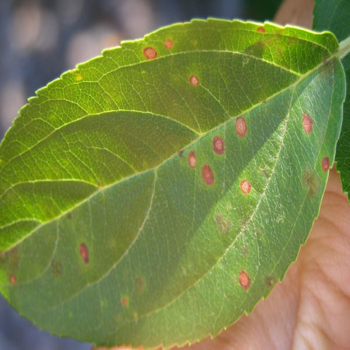


[ConvNeXt 단독]
Top1: Apple___Apple_scab / 0.9639
Top2: Apple___healthy / 0.0198
Top3: Apple___Black_rot / 0.0087

[YOLO Threshold 비교]
--------------------------------------------------------------------------------
threshold = 0.05
YOLO detected: True
YOLO conf: 0.5449
YOLO box count: 25
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.08
YOLO detected: True
YOLO conf: 0.5449
YOLO box count: 18
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.1
YOLO detected: True
YOLO conf: 0.5449
YOLO box count: 15
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.15
YOLO detected: True
YOLO conf: 0.5449
YOLO box count: 13
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.2
YOLO detected:

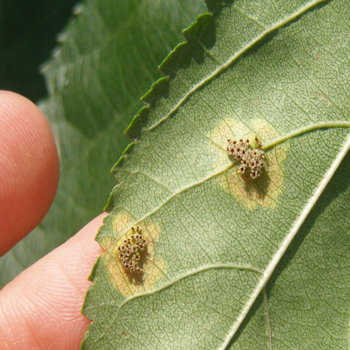


[ConvNeXt 단독]
Top1: Grape___Black_rot / 0.7967
Top2: Apple___Cedar_apple_rust / 0.1066
Top3: Apple___Black_rot / 0.0783

[YOLO Threshold 비교]
--------------------------------------------------------------------------------
threshold = 0.05
YOLO detected: True
YOLO conf: 0.7204
YOLO box count: 5
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.08
YOLO detected: True
YOLO conf: 0.7204
YOLO box count: 4
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.1
YOLO detected: True
YOLO conf: 0.7204
YOLO box count: 3
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.15
YOLO detected: True
YOLO conf: 0.7204
YOLO box count: 2
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.2
YOLO detec

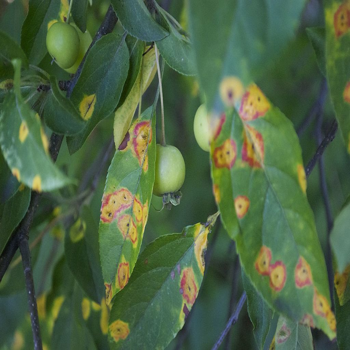


[ConvNeXt 단독]
Top1: Apple___Black_rot / 0.6907
Top2: Pepper,_bell___Bacterial_spot / 0.1349
Top3: Apple___Cedar_apple_rust / 0.1184

[YOLO Threshold 비교]
--------------------------------------------------------------------------------
threshold = 0.05
YOLO detected: True
YOLO conf: 0.5852
YOLO box count: 19
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.08
YOLO detected: True
YOLO conf: 0.5852
YOLO box count: 14
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.1
YOLO detected: True
YOLO conf: 0.5852
YOLO box count: 10
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.15
YOLO detected: True
YOLO conf: 0.5852
YOLO box count: 6
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold =

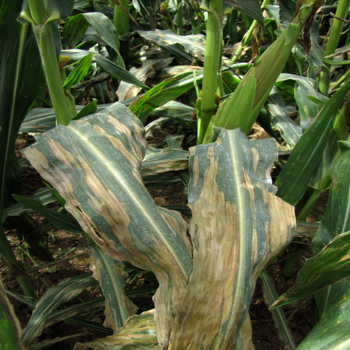


[ConvNeXt 단독]
Top1: Corn_(maize)___Common_rust_ / 0.9303
Top2: Corn_(maize)___Northern_Leaf_Blight / 0.0697
Top3: Apple___Cedar_apple_rust / 0.0

[YOLO Threshold 비교]
--------------------------------------------------------------------------------
threshold = 0.05
YOLO detected: True
YOLO conf: 0.5053
YOLO box count: 27
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.08
YOLO detected: True
YOLO conf: 0.5053
YOLO box count: 18
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.1
YOLO detected: True
YOLO conf: 0.5053
YOLO box count: 16
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.15
YOLO detected: True
YOLO conf: 0.5053
YOLO box count: 7
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
-------------------------------------------------------------------------------

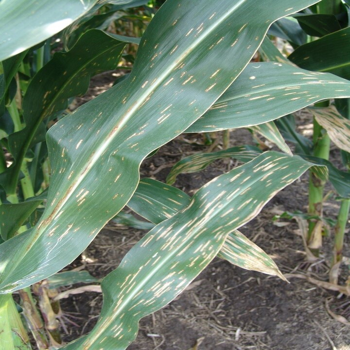


[ConvNeXt 단독]
Top1: Corn_(maize)___Northern_Leaf_Blight / 0.5627
Top2: Corn_(maize)___Common_rust_ / 0.4354
Top3: Apple___Cedar_apple_rust / 0.0005

[YOLO Threshold 비교]
--------------------------------------------------------------------------------
threshold = 0.05
YOLO detected: True
YOLO conf: 0.2797
YOLO box count: 24
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.08
YOLO detected: True
YOLO conf: 0.2797
YOLO box count: 12
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.1
YOLO detected: True
YOLO conf: 0.2797
YOLO box count: 8
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.15
YOLO detected: True
YOLO conf: 0.2797
YOLO box count: 2
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
-----------------------------------------------------------------------------

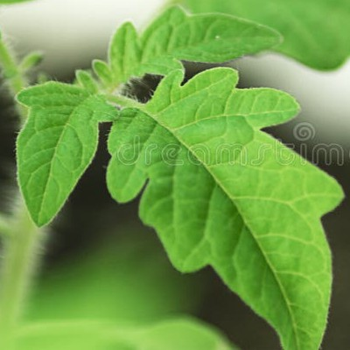


[ConvNeXt 단독]
Top1: Tomato___Late_blight / 0.9936
Top2: Tomato___healthy / 0.0054
Top3: Corn_(maize)___healthy / 0.0004

[YOLO Threshold 비교]
--------------------------------------------------------------------------------
threshold = 0.05
YOLO detected: True
YOLO conf: 0.0728
YOLO box count: 4
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.08
YOLO detected: False
YOLO conf: 0.0
YOLO box count: 0
Decision: 병반 미탐지 + disease → 판단 어려움
--------------------------------------------------------------------------------
threshold = 0.1
YOLO detected: False
YOLO conf: 0.0
YOLO box count: 0
Decision: 병반 미탐지 + disease → 판단 어려움
--------------------------------------------------------------------------------
threshold = 0.15
YOLO detected: False
YOLO conf: 0.0
YOLO box count: 0
Decision: 병반 미탐지 + disease → 판단 어려움
--------------------------------------------------------------------------------
threshold = 0.2
YOLO detec

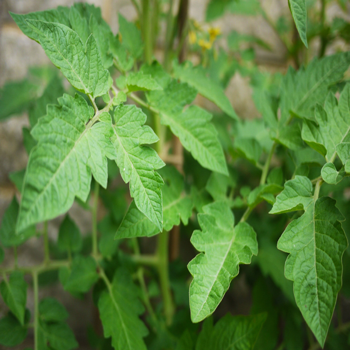


[ConvNeXt 단독]
Top1: Apple___Apple_scab / 0.8217
Top2: Apple___Cedar_apple_rust / 0.132
Top3: Apple___healthy / 0.0176

[YOLO Threshold 비교]
--------------------------------------------------------------------------------
threshold = 0.05
YOLO detected: False
YOLO conf: 0.0
YOLO box count: 0
Decision: 병반 미탐지 + disease → 판단 어려움
--------------------------------------------------------------------------------
threshold = 0.08
YOLO detected: False
YOLO conf: 0.0
YOLO box count: 0
Decision: 병반 미탐지 + disease → 판단 어려움
--------------------------------------------------------------------------------
threshold = 0.1
YOLO detected: False
YOLO conf: 0.0
YOLO box count: 0
Decision: 병반 미탐지 + disease → 판단 어려움
--------------------------------------------------------------------------------
threshold = 0.15
YOLO detected: False
YOLO conf: 0.0
YOLO box count: 0
Decision: 병반 미탐지 + disease → 판단 어려움
--------------------------------------------------------------------------------
threshold = 0.2
YOLO detecte

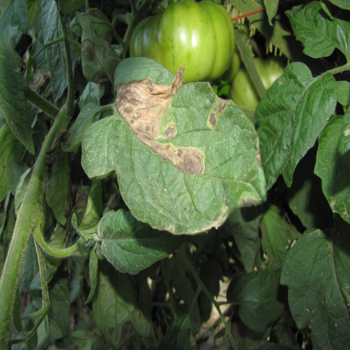


[ConvNeXt 단독]
Top1: Apple___Black_rot / 0.9363
Top2: Apple___Cedar_apple_rust / 0.0411
Top3: Apple___Apple_scab / 0.0096

[YOLO Threshold 비교]
--------------------------------------------------------------------------------
threshold = 0.05
YOLO detected: True
YOLO conf: 0.619
YOLO box count: 6
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.08
YOLO detected: True
YOLO conf: 0.619
YOLO box count: 5
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.1
YOLO detected: True
YOLO conf: 0.619
YOLO box count: 5
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.15
YOLO detected: True
YOLO conf: 0.619
YOLO box count: 4
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.2
YOLO detected

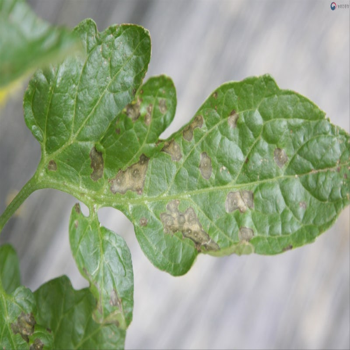


[ConvNeXt 단독]
Top1: Apple___Apple_scab / 0.9982
Top2: Apple___Black_rot / 0.0007
Top3: Tomato___Early_blight / 0.0006

[YOLO Threshold 비교]
--------------------------------------------------------------------------------
threshold = 0.05
YOLO detected: True
YOLO conf: 0.3632
YOLO box count: 12
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.08
YOLO detected: True
YOLO conf: 0.3632
YOLO box count: 7
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.1
YOLO detected: True
YOLO conf: 0.3632
YOLO box count: 7
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.15
YOLO detected: True
YOLO conf: 0.3632
YOLO box count: 4
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.2
YOLO detect

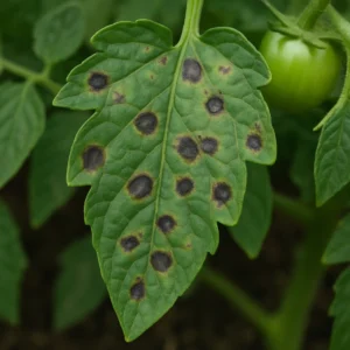


[ConvNeXt 단독]
Top1: Tomato___Early_blight / 0.4148
Top2: Tomato___Late_blight / 0.3123
Top3: Apple___Black_rot / 0.237

[YOLO Threshold 비교]
--------------------------------------------------------------------------------
threshold = 0.05
YOLO detected: True
YOLO conf: 0.7846
YOLO box count: 33
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.08
YOLO detected: True
YOLO conf: 0.7846
YOLO box count: 21
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.1
YOLO detected: True
YOLO conf: 0.7846
YOLO box count: 19
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.15
YOLO detected: True
YOLO conf: 0.7846
YOLO box count: 17
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.2
YOLO de

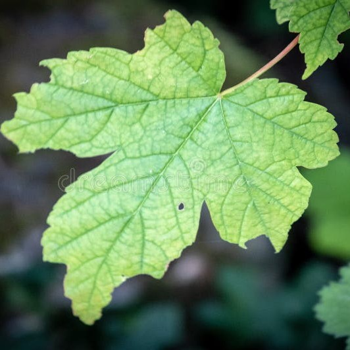


[ConvNeXt 단독]
Top1: Tomato___Septoria_leaf_spot / 0.3268
Top2: Apple___Apple_scab / 0.1704
Top3: Apple___Black_rot / 0.1641

[YOLO Threshold 비교]
--------------------------------------------------------------------------------
threshold = 0.05
YOLO detected: False
YOLO conf: 0.0
YOLO box count: 0
Decision: 병반 미탐지 + disease → 판단 어려움
--------------------------------------------------------------------------------
threshold = 0.08
YOLO detected: False
YOLO conf: 0.0
YOLO box count: 0
Decision: 병반 미탐지 + disease → 판단 어려움
--------------------------------------------------------------------------------
threshold = 0.1
YOLO detected: False
YOLO conf: 0.0
YOLO box count: 0
Decision: 병반 미탐지 + disease → 판단 어려움
--------------------------------------------------------------------------------
threshold = 0.15
YOLO detected: False
YOLO conf: 0.0
YOLO box count: 0
Decision: 병반 미탐지 + disease → 판단 어려움
--------------------------------------------------------------------------------
threshold = 0.2
YOLO d

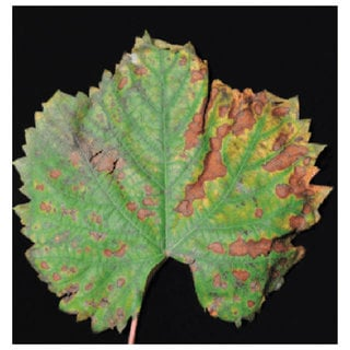


[ConvNeXt 단독]
Top1: Tomato___Septoria_leaf_spot / 0.6848
Top2: Apple___Cedar_apple_rust / 0.2903
Top3: Raspberry___healthy / 0.0222

[YOLO Threshold 비교]
--------------------------------------------------------------------------------
threshold = 0.05
YOLO detected: True
YOLO conf: 0.4757
YOLO box count: 16
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.08
YOLO detected: True
YOLO conf: 0.4757
YOLO box count: 12
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.1
YOLO detected: True
YOLO conf: 0.4757
YOLO box count: 10
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold = 0.15
YOLO detected: True
YOLO conf: 0.4757
YOLO box count: 9
Decision: 병반 탐지됨 → ConvNeXt 결과 사용
--------------------------------------------------------------------------------
threshold =

In [28]:
# ============================================================
# 18. 이미지 + ConvNeXt 단독 + threshold 5개 결과 출력
# ============================================================

for row in compare_multi_rows:
    img_path = Path(row["img_path"])

    print("=" * 130)
    print("파일명:", row["file_name"])
    print("selected_crop:", row["selected_crop"])

    display(Image.open(img_path).resize((350, 350)))

    print("\n[ConvNeXt 단독]")
    print("Top1:", row["conv_only_top1"], "/", row["conv_only_top1_conf"])
    print("Top2:", row["conv_only_top2"], "/", row["conv_only_top2_conf"])
    print("Top3:", row["conv_only_top3"], "/", row["conv_only_top3_conf"])

    print("\n[YOLO Threshold 비교]")

    for thres in YOLO_THRESHOLDS:
        thres_key = str(thres).replace(".", "_")

        print("-" * 80)
        print(f"threshold = {thres}")
        print("YOLO detected:", row[f"yolo_{thres_key}_detected"])
        print("YOLO conf:", row[f"yolo_{thres_key}_conf"])
        print("YOLO box count:", row[f"yolo_{thres_key}_box_count"])
        print("Decision:", row[f"mode_a_{thres_key}_decision"])